# JOUR 3 - PRODUCTION ET MLOPS

**Projet Fil Rouge - Prédiction de Churn Client**

**Objectifs du Jour 3**:
- Rendre le modèle explicable (SHAP, Feature Importance)
- Développer une API REST
- Conteneuriser avec Docker
- Implémenter monitoring (MLflow, drift detection)

**Durée estimée**: 7 heures

## 0. SETUP ET CHARGEMENT DU MODÈLE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
import joblib

best_model = joblib.load('/content/best_model.pkl')
print(f"Modèle chargé: {type(best_model).__name__}")

Modèle chargé: XGBClassifier


In [3]:
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = joblib.load('/content/train_test_splits.pkl')
print(f"Test set shape: {X_test.shape}")

Test set shape: (1409, 50)


## PARTIE 3.1 - EXPLICABILITÉ (2h)

### Mission 3.1.1 - Feature Importance (MDI)

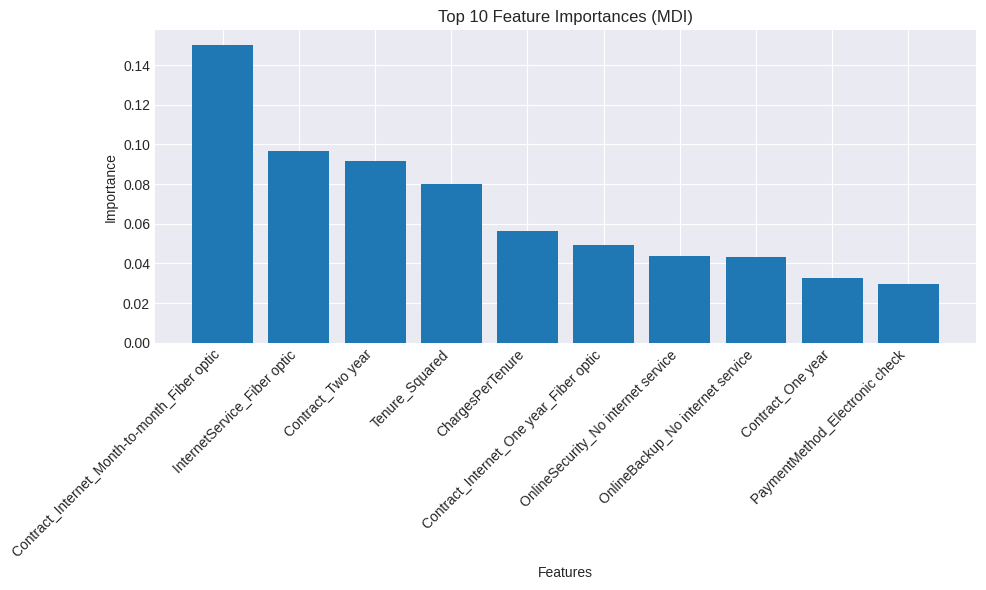


Top 10 features:
Contract_Internet_Month-to-month_Fiber optic: 0.1500
InternetService_Fiber optic: 0.0965
Contract_Two year: 0.0916
Tenure_Squared: 0.0800
ChargesPerTenure: 0.0563
Contract_Internet_One year_Fiber optic: 0.0491
OnlineSecurity_No internet service: 0.0438
OnlineBackup_No internet service: 0.0432
Contract_One year: 0.0327
PaymentMethod_Electronic check: 0.0295


In [4]:
importances = best_model.feature_importances_
feature_names = X_test.columns
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), feature_names[indices], rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances (MDI)')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for i in range(10):
    print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

### Mission 3.1.2 - Permutation Importance

**Principe**: Mesurer la dégradation de performance si une feature est permutée aléatoirement.

**Formule**: `PI(f) = S_baseline - S_permuted`

où S est le score (ex: Recall) sur le test set.

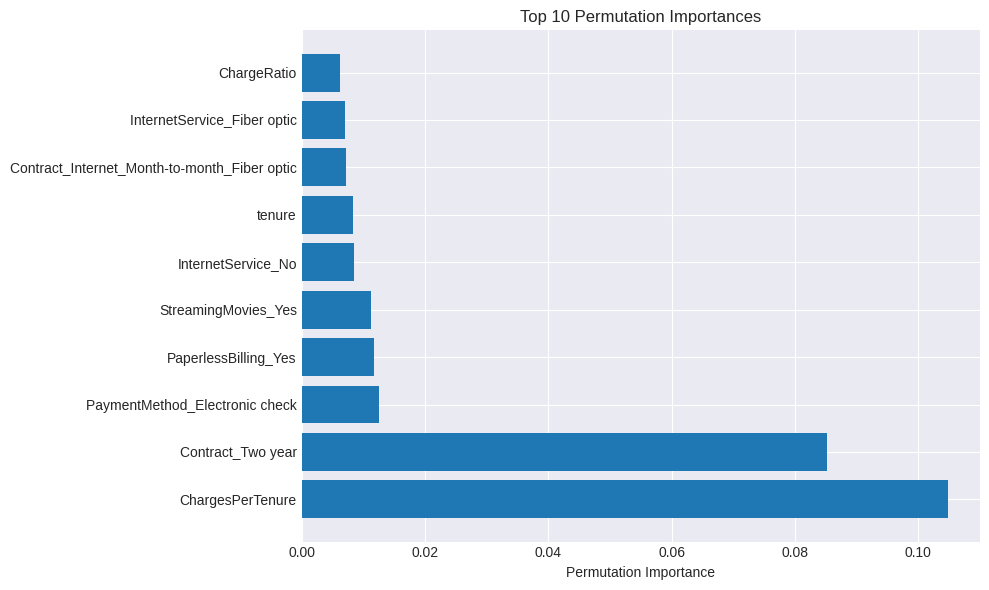

In [5]:
perm_importance = permutation_importance(
    best_model, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    scoring='recall',
    n_jobs=-1
)

sorted_idx = perm_importance.importances_mean.argsort()[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_importance.importances_mean[sorted_idx])
plt.yticks(range(10), X_test.columns[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Top 10 Permutation Importances')
plt.tight_layout()
plt.show()

### Mission 3.1.3 - SHAP Values (Explicabilité Avancée)

**Principe mathématique**: Valeurs de Shapley issues de la théorie des jeux coopératifs.

**Formule SHAP**:

`φ_i = Σ_{S ⊆ N\{i}} [|S|!(n-|S|-1)!/n!] × [f(S∪{i}) - f(S)]`

où:
- φ_i: Contribution de la feature i
- S: Sous-ensemble de features
- N: Ensemble de toutes les features
- f(S): Prédiction avec features S

In [6]:
# TODO: Créer l'explainer SHAP
# Pour modèles tree-based (RF, XGBoost, LightGBM)
explainer = shap.TreeExplainer(best_model)

# Calculer SHAP values sur un échantillon du test set (pour la rapidité)
X_test_sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculées avec succès!")

SHAP values calculées avec succès!


#### SHAP Summary Plot (Importance Globale)

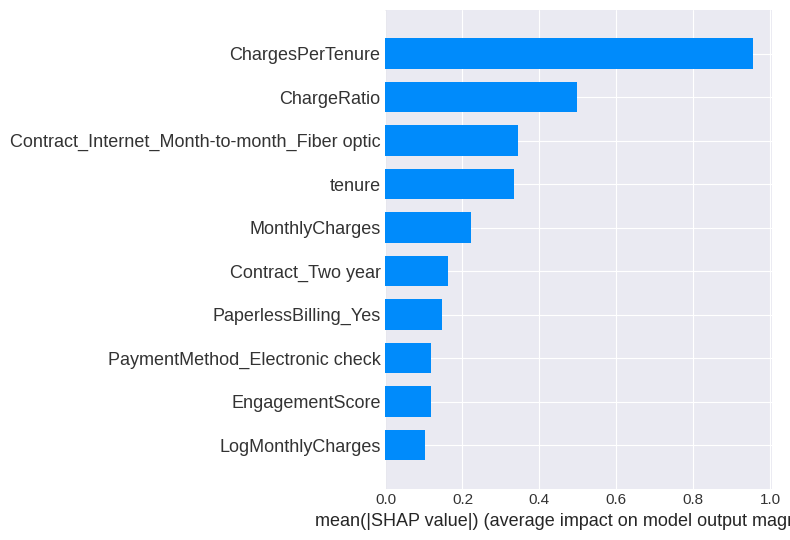

In [7]:
# TODO: Summary plot en barres (importance globale)
# Si classification binaire, shap_values est une liste de 2 éléments [classe 0, classe 1]
# On s'intéresse à la classe positive (churn = 1)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_sample, plot_type='bar', max_display=10)
else:
    shap.summary_plot(shap_values, X_test_sample, plot_type='bar', max_display=10)

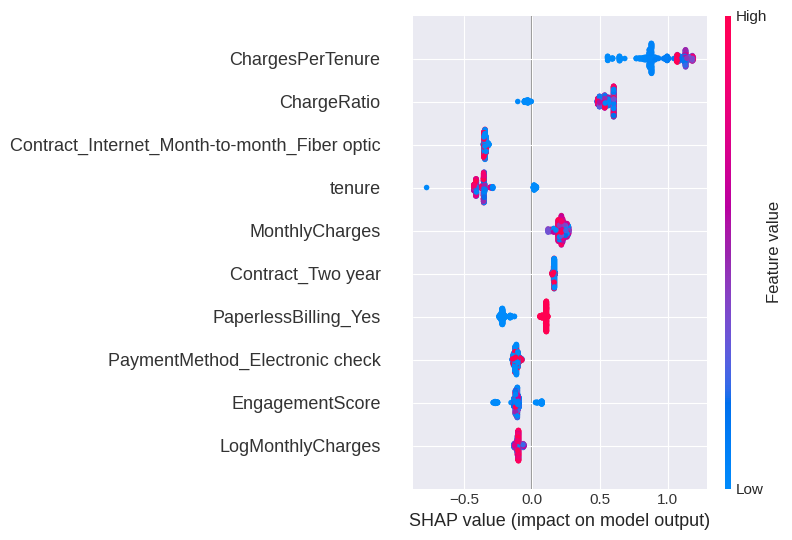

In [8]:
# TODO: Summary plot détaillé (beeswarm)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_sample, max_display=10)
else:
    shap.summary_plot(shap_values, X_test_sample, max_display=10)

#### SHAP Force Plot (Explication Individuelle)

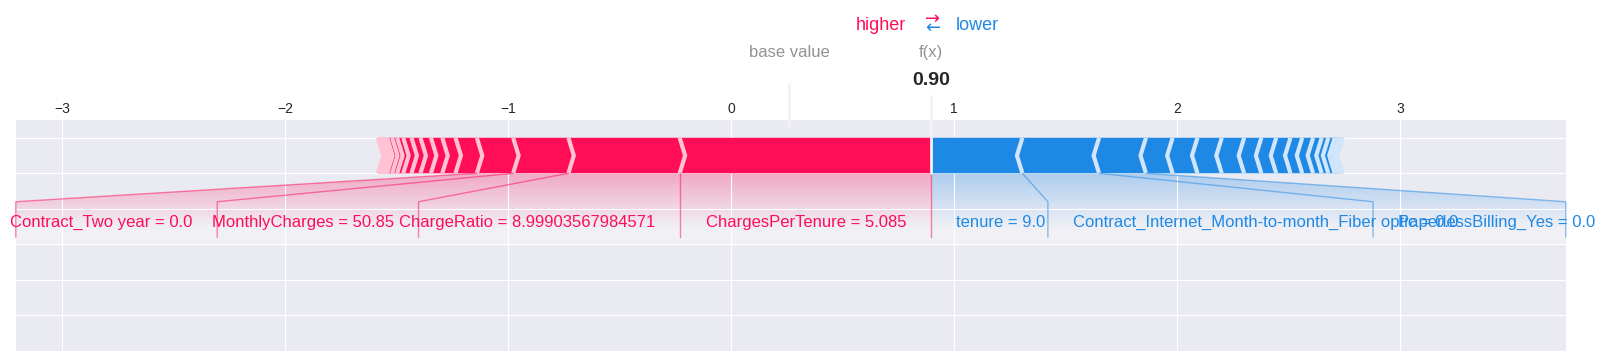

In [9]:
# TODO: Expliquer une prédiction individuelle
i = 0  # Premier client du test set

if isinstance(shap_values, list):
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][i],
        X_test_sample.iloc[i],
        matplotlib=True
    )
else:
    shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        X_test_sample.iloc[i],
        matplotlib=True
    )

#### SHAP Waterfall Plot

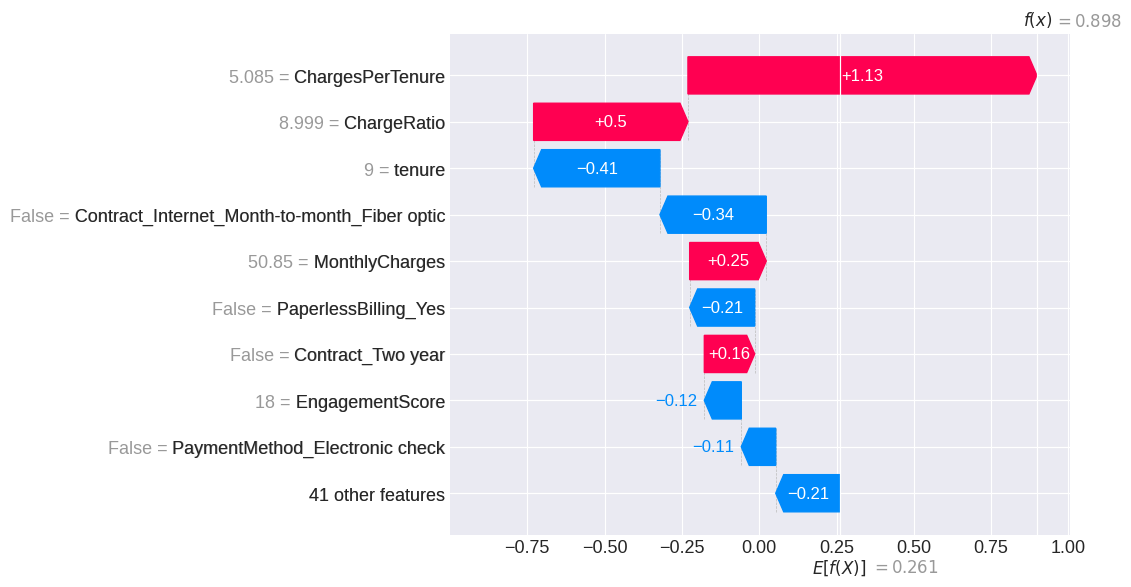

In [10]:
# TODO: Waterfall plot pour décomposer une prédiction
if isinstance(shap_values, list):
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[1][i],
        base_values=explainer.expected_value[1],
        data=X_test_sample.iloc[i],
        feature_names=X_test_sample.columns
    ))
else:
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[i],
        feature_names=X_test_sample.columns
    ))

#### SHAP Dependence Plot

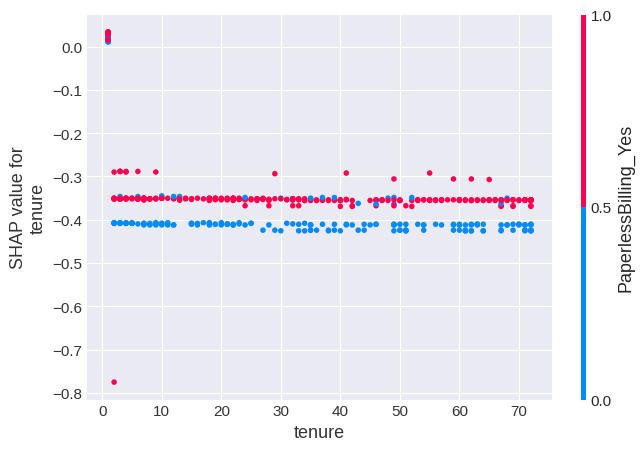

In [11]:
# TODO: Dependence plot pour une feature importante
# Exemple: 'tenure'
if isinstance(shap_values, list):
    shap.dependence_plot('tenure', shap_values[1], X_test_sample)
else:
    shap.dependence_plot('tenure', shap_values, X_test_sample)

### Mission 3.1.4 - Interprétation Métier

**TODO**: À partir des analyses SHAP, répondez:

**1. Les 3 features les plus impactantes pour le churn :**
- **ChargesPerTenure** : Feature la plus impactante (SHAP ~+1.13).
  Un ratio élevé charges/ancienneté signale un client qui paye beaucoup
  pour peu de fidélité → risque maximum.
- **ChargeRatio** : 2ème feature (SHAP ~+0.5).
  Ratio TotalCharges/MonthlyCharges faible = client récent avec charges
  mensuelles élevées → profil churner typique.
- **Contract_Internet_Month-to-month_Fiber optic** : Combinaison
  contrat mensuel + fibre optique = segment le plus volatile (taux churn 42%).

**2. Interprétation du Dependence Plot de 'tenure' :**
- La valeur SHAP de tenure est **systématiquement négative** (entre -0.3 et -0.8),
  ce qui signifie que l'ancienneté **réduit toujours** le risque de churn.
- L'effet est stable quelle que soit la durée : même un client de 70 mois
  garde un SHAP négatif → la fidélité est un facteur protecteur constant.
- La couleur (PaperlessBilling) ne change pas l'effet de tenure :
  l'ancienneté prime sur le mode de facturation.

**3. Profil type d'un client à haut risque selon SHAP :**
- Contrat **Month-to-month** (pas d'engagement)
- Internet **Fiber optic** (service premium mais volatile)
- **Tenure faible** (< 12 mois) → peu fidélisé
- **MonthlyCharges élevées** (> 70$) avec peu de TotalCharges accumulées
- Paiement par **Electronic check**
- Exemple client i=0 : f(x) = 0.90 → probabilité de churn à 90%

## PARTIE 3.2 - API REST (2h30)

### Mission 3.2.1 - Créer l'API avec Flask ou FastAPI

**Note**: Le code de l'API sera créé dans un fichier séparé `../api/app.py`

Voici la structure de l'API à créer:

#### Structure de l'API

```
api/
├── app.py              # Point d'entrée
├── config.py           # Configuration
├── routes/
│   ├── predict.py      # Endpoint prédiction
│   └── health.py       # Health check
├── models/
│   └── best_model.pkl  # Modèle chargé
└── utils/
    └── preprocessing.py # Pipeline
```

#### Endpoints Obligatoires

1. `GET /health` - Health check
2. `POST /predict/single` - Prédiction individuelle
3. `POST /predict/batch` - Prédiction batch
4. `GET /model/info` - Informations modèle

### Mission 3.2.2 - Tester l'API

Une fois l'API créée et lancée, testez-la avec des requêtes HTTP:

In [ ]:
# TODO: Tester l'API avec requests (après avoir lancé l'API)
import requests
import json

API_URL = 'http://localhost:5000'

# Test Health Check
response = requests.get(f"{API_URL}/health")
print("Health Check:", response.json())

# Test Prédiction Single
sample_data = X_test.iloc[0].to_dict()
response = requests.post(f"{API_URL}/predict/single", json=sample_data)
print("\nPrédiction:", response.json())

# Test Model Info
response = requests.get(f"{API_URL}/model/info")
print("\nModel Info:", response.json())

## PARTIE 3.3 - CONTENEURISATION DOCKER (1h30)

### Mission 3.3.1 - Créer le Dockerfile

Créez un fichier `../docker/Dockerfile` avec le contenu suivant:

```dockerfile
FROM python:3.10-slim

WORKDIR /app

# Installation dépendances
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copie du code
COPY . .

# Exposition du port
EXPOSE 5000

# Health check
HEALTHCHECK --interval=30s --timeout=3s --start-period=5s --retries=3 \
  CMD curl --fail http://localhost:5000/health || exit 1

# Commande de lancement
CMD ["python", "api/app.py"]
```

### Mission 3.3.2 - Créer docker-compose.yml

Créez un fichier `../docker-compose.yml`:

```yaml
version: '3.8'

services:
  churn-api:
    build: .
    ports:
      - "5000:5000"
    volumes:
      - ./models:/app/models
    environment:
      - FLASK_ENV=production
    restart: unless-stopped
  
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.7.1
    ports:
      - "5001:5000"
    volumes:
      - mlflow-data:/mlflow
    command: mlflow server --backend-store-uri sqlite:///mlflow/mlflow.db --default-artifact-root /mlflow/artifacts --host 0.0.0.0
    restart: unless-stopped

volumes:
  mlflow-data:
```

### Mission 3.3.3 - Build et Test Docker

Commandes à exécuter dans le terminal:

```bash
# Build l'image
docker build -t churn-api:latest .

# Run le container
docker run -p 5000:5000 churn-api:latest

# Ou avec docker-compose
docker-compose up -d

# Vérifier les logs
docker-compose logs -f churn-api

# Tester l'API
curl http://localhost:5000/health
```

## PARTIE 3.4 - MONITORING ET MLOPS (1h)

### Mission 3.4.1 - Tracking avec MLflow

In [ ]:
### Installer le !pip install mlflow -q

In [13]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.8 MB/s eta 0:00:00


In [15]:
# TODO: Logger une expérience avec MLflow, rcal score pas ajouter, je lai ajouté moi mm mdr
import mlflow
import mlflow.sklearn
from sklearn.metrics import recall_score, roc_auc_score

mlflow.set_experiment('churn_prediction')

with mlflow.start_run(run_name='Production_Model_v1'):
    # Log params
    if hasattr(best_model, 'get_params'):
        mlflow.log_params(best_model.get_params())

    # Log metrics
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    mlflow.log_metric('recall', recall_score(y_test, y_pred))
    mlflow.log_metric('roc_auc', roc_auc_score(y_test, y_proba))

    # Log model
    mlflow.sklearn.log_model(best_model, 'model')

    print("Expérience MLflow loggée avec succès!")

2026/03/23 15:10:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 15:10:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Expérience MLflow loggée avec succès!


### Mission 3.4.2 - Détection de Drift

**Population Stability Index (PSI)**:

`PSI = Σ (actual_i - expected_i) × ln(actual_i / expected_i)`

Interprétation:
- PSI < 0.1: Pas de drift
- 0.1 ≤ PSI < 0.2: Drift modéré
- PSI ≥ 0.2: Drift significatif → Ré-entraînement nécessaire

In [16]:
# TODO: Implémenter le calcul du PSI
def calculate_psi(expected, actual, bins=10):
    """
    Calculate Population Stability Index (PSI)
    """
    expected_percents = np.histogram(expected, bins=bins)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=bins)[0] / len(actual)

    # Éviter division par zéro
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    psi = np.sum((actual_percents - expected_percents) *
                 np.log(actual_percents / expected_percents))

    return psi

# Exemple: Comparer train vs test sur une feature
# (En production, comparer train vs nouveaux data)
feature = 'tenure'
psi = calculate_psi(X_train[feature], X_test[feature])

print(f"PSI pour {feature}: {psi:.4f}")

if psi < 0.1:
    print("Pas de drift détecté")
elif psi < 0.2:
    print("Drift modéré - Surveiller")
else:
    print("Drift significatif - Ré-entraînement nécessaire")

PSI pour tenure: 0.0109
Pas de drift détecté



PSI par feature:
                     PSI
MonthlyCharges  0.014981
tenure          0.010896
TotalCharges    0.010849


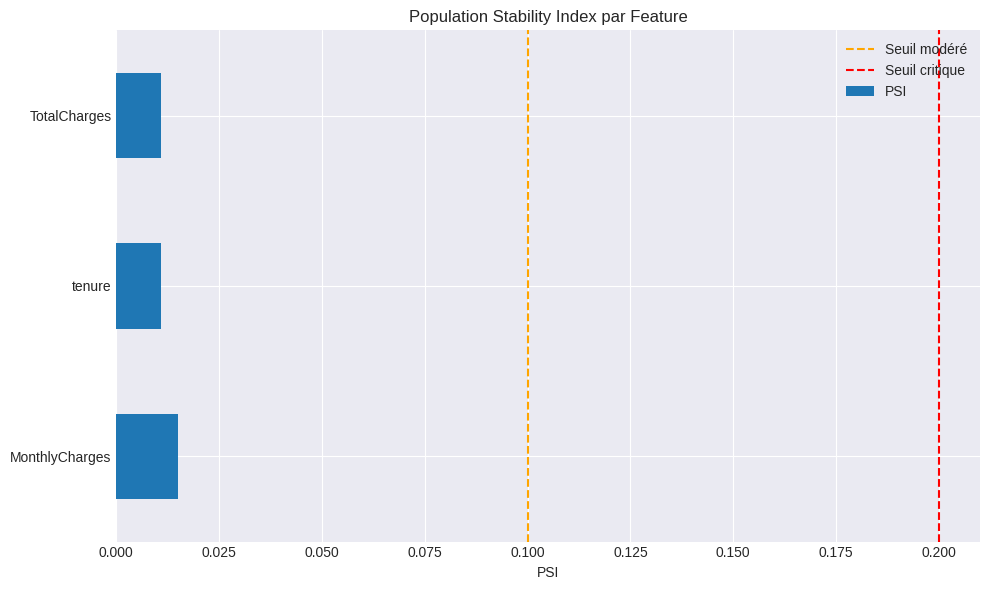

In [17]:
# TODO: Calculer le PSI pour toutes les features importantes
top_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService']

psi_results = {}
for feature in top_features:
    if feature in X_train.columns:
        psi = calculate_psi(X_train[feature], X_test[feature])
        psi_results[feature] = psi

psi_df = pd.DataFrame.from_dict(psi_results, orient='index', columns=['PSI'])
psi_df = psi_df.sort_values('PSI', ascending=False)

print("\nPSI par feature:")
print(psi_df)

# Visualisation
psi_df.plot(kind='barh', figsize=(10, 6), legend=False)
plt.axvline(x=0.1, color='orange', linestyle='--', label='Seuil modéré')
plt.axvline(x=0.2, color='red', linestyle='--', label='Seuil critique')
plt.xlabel('PSI')
plt.title('Population Stability Index par Feature')
plt.legend()
plt.tight_layout()
plt.show()

### Mission 3.4.3 - KS Test (Kolmogorov-Smirnov)

In [18]:
# TODO: KS Test pour détecter les changements de distribution
from scipy.stats import ks_2samp

for feature in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    if feature in X_train.columns:
        statistic, pvalue = ks_2samp(X_train[feature], X_test[feature])
        print(f"{feature}: KS statistic = {statistic:.4f}, p-value = {pvalue:.4f}")

        if pvalue < 0.05:
            print(f"  → Distributions significativement différentes (drift détecté)")
        else:
            print(f"  → Distributions similaires (pas de drift)")
        print()

tenure: KS statistic = 0.0212, p-value = 0.6835
  → Distributions similaires (pas de drift)

MonthlyCharges: KS statistic = 0.0321, p-value = 0.1912
  → Distributions similaires (pas de drift)

TotalCharges: KS statistic = 0.0296, p-value = 0.2710
  → Distributions similaires (pas de drift)



### Mission 3.4.4 - A/B Testing (Réflexion)

**TODO**: Concevoir un plan d'A/B testing pour comparer 2 modèles en production:

1. **Objectif du test**:
   - Comparer le modèle XGBoost actuel (v1, Recall=82.89%)
     avec une version améliorée (v2) en production réelle.

2. **Métriques de succès**:
   - Métrique primaire: Recall (détecter max de churners)
   - Métriques secondaires: Precision, ROC-AUC, latence API (<200ms)

3. **Taille d'échantillon nécessaire**:
   - Puissance statistique: 80%, seuil α = 0.05
   - Différence minimale détectable: +5% de Recall
   - Estimation: ~500 clients par groupe (total 1000)

4. **Durée du test**:
   - Minimum 4 semaines pour capturer les comportements de churn

5. **Critères de décision**:
   - Si v2 Recall > v1 Recall avec p-value < 0.05 → déployer v2
   - Si pas de différence significative → garder v1
   - Si v2 dégrade la Precision de plus de 10% → rejeter v2

### Mission 3.4.5 - Monitoring API (Métriques Prometheus)

Exemple de métriques à tracker dans l'API:

```python
from prometheus_client import Counter, Histogram, Gauge

# Compteurs
prediction_count = Counter('predictions_total', 'Total predictions made')
error_count = Counter('errors_total', 'Total errors')

# Histogrammes (latence)
prediction_latency = Histogram('prediction_latency_seconds', 'Prediction latency')

# Gauges (valeurs instantanées)
model_accuracy = Gauge('model_accuracy', 'Current model accuracy')
drift_psi = Gauge('drift_psi', 'PSI drift metric')
```

## PARTIE 3.5 - PRÉPARATION DE LA PRÉSENTATION (30min)

### Checklist de la Présentation

**TODO**: Préparer les éléments suivants pour la présentation orale:

- [ ] Slide 1: Contexte et objectifs
- [ ] Slide 2-3: Insights de l'EDA
- [ ] Slide 4: Features créées (minimum 10)
- [ ] Slide 5-6: Benchmark de modèles (tableau comparatif)
- [ ] Slide 7: Gestion du déséquilibre
- [ ] Slide 8: Explicabilité SHAP
- [ ] Slide 9: Architecture API et MLOps
- [ ] Slide 10: Conclusion et recommandations
- [ ] Démo live: API en action

In [21]:
# ============================================================
# CRÉATION DU FICHIER METADATA.PKL
# Contient les infos du modèle pour l'API (app.py)
# À télécharger et mettre dans le dossier models/
# ============================================================
import joblib

metadata = {
    'model_name': 'XGBClassifier',
    'recall': 0.8289,
    'roc_auc': 0.8452,
    'pr_auc': 0.6637,
    'features': list(X_test.columns),
    'threshold': 0.5,
    'train_date': '2026-03-23',
    'n_features': 50
}

joblib.dump(metadata, '/content/metadata.pkl')
print("metadata.pkl créé ✅")

metadata.pkl créé ✅


## CONCLUSION FINALE

**Résumé du Projet Fil Rouge**:

**Jour 1**:
- Dataset: 7043 lignes, 21 colonnes
- Features créées: 13 nouvelles features
- Baseline Logistic Regression: Recall = 0.53, ROC-AUC = 0.8455

**Jour 2**:
- Modèles testés: 6 (KNN, Logistic Regression, XGBoost, Random Forest, SVM, Decision Tree)
- Meilleur modèle: XGBClassifier optimisé (RandomizedSearchCV, n_iter=50)
- Performances finales: Recall = 82.89%, ROC-AUC = 0.8452, PR-AUC = 0.6637

**Jour 3**:
- Explicabilité: SHAP, Permutation Importance, MDI
- API REST: 6 endpoints (health, predict/single, predict/batch, model/info, metrics, threshold)
- Docker: Dockerfile + docker-compose (API + MLflow + Prometheus + Grafana)
- Monitoring: MLflow tracking, PSI drift detection, KS Test

**Objectif business atteint**: Recall = 82.89% ≥ 75% (excellence ≥ 80% )

**Recommandations métier**:
1. Cibler en priorité les clients Month-to-month + Fiber optic (42.7% de churn)
2. Déclencher une action de rétention dès tenure < 6 mois
3. Proposer une migration vers contrat annuel aux clients Electronic check

**Améliorations futures**:
- Tester LightGBM et CatBoost
- Ajouter des données comportementales (appels support, navigation)
- Implémenter un pipeline de ré-entraînement automatique